In [13]:
import io
import numpy as np
import pandas as pd
from typing import List

print("--- 1. INITIALIZING FUNCTIONS ---")

def entropy(labels: List[str]) -> float:
    if not labels:
        return 0.0
    counts = pd.Series(labels).value_counts()
    proportions = counts / len(labels)
    return float(-np.sum(proportions * np.log2(proportions)))

def information_gain(data: pd.DataFrame, attribute: str, target: str) -> float:
    parent_entropy = entropy(data[target].tolist())
    total_samples = len(data)
    weighted_subset_entropy = 0.0
    for val, subset in data.groupby(attribute):
        subset_entropy = entropy(subset[target].tolist())
        weight = len(subset) / total_samples
        weighted_subset_entropy += weight * subset_entropy
    return float(parent_entropy - weighted_subset_entropy)

print("Functions loaded successfully!")
print("\n--- 2. RUNNING TEST 1: RAW ENTROPY ---")
entropy_test = entropy(['yes', 'yes', 'no', 'yes'])
print(f"Calculated Entropy: {entropy_test}")

print("\n--- 3. RUNNING TEST 2: LOADING TENNIS DATA ---")
try:
    tennis_url = "https://raw.githubusercontent.com/lmassaron/datasets/master/tennis.csv"
    tennis_df = pd.read_csv(tennis_url)
    tennis_df.columns = ['Outlook', 'Temperature', 'Humidity', 'Wind', 'Play']
    print("Tennis Data Loaded! Top 2 rows:")
    print(tennis_df.head(2))
    
    outlook_gain =information_gain(tennis_df, 'Outlook', 'Play')
    print(f"Outlook Information Gain: {outlook_gain:.4f}")
except Exception as e:
    print(f"Network error loading Tennis data: {e}")

--- 1. INITIALIZING FUNCTIONS ---
Functions loaded successfully!

--- 2. RUNNING TEST 1: RAW ENTROPY ---
Calculated Entropy: 0.8112781244591328

--- 3. RUNNING TEST 2: LOADING TENNIS DATA ---
Network error loading Tennis data: <urlopen error [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond>


In [15]:
print("\n--- 4. Executing Task 1.4: Constructing the ID3 Tree ---")

# Define the feature set columns (excluding the target column 'Play')
feature_columns = ['Outlook', 'Temperature', 'Humidity', 'Wind']

# Generate the full recursive tree
built_tree = id3(tennis_df, feature_columns, 'Play')

# Use Python's built-in json tool to print the tree dictionary neatly
import json
print(json.dumps(built_tree, indent=4))


--- 4. Executing Task 1.4: Constructing the ID3 Tree ---
{
    "Outlook": {
        "Sunny": {
            "Humidity": {
                "High": 0,
                "Normal": 1
            }
        },
        "Overcast": 1,
        "Rain": {
            "Wind": {
                "Weak": 1,
                "Strong": 0
            }
        }
    }
}


In [14]:
def id3(data: pd.DataFrame, features: list, target: str) -> dict or str:
    """
    Recursively builds a decision tree using the ID3 algorithm.
    """
    # Grab the target column labels (e.g., ['yes', 'no', 'yes'...])
    target_labels = data[target].tolist()
    
    # --- BASE CASE 1: Homogeneous Node ---
    # If all samples have the same target value, return that value (Leaf Node)
    if len(set(target_labels)) == 1:
        return target_labels[0]
        
    # --- BASE CASE 2: No Features Left ---
    # If features list is empty, return the majority target value in the current data
    if not features:
        return data[target].mode()[0]
        
    # --- STEP 3: Find the Best Feature to Split On ---
    # Calculate Information Gain for all remaining features
    gains = {feat: information_gain(data, feat, target) for feat in features}
    
    # Pick the feature with the highest Information Gain
    best_feature = max(gains, key=gains.get)
    
    # Initialize our tree node structure
    tree = {best_feature: {}}
    
    # --- STEP 4: Split and Recurse ---
    # Get all unique values of the best feature (e.g., 'Sunny', 'Overcast', 'Rain')
    feature_values = data[best_feature].unique()
    
    # Remove the chosen feature from the list so child branches don't recalculate it
    remaining_features = [f for f in features if f != best_feature]
    
    for val in feature_values:
        # Create a subset of data containing only rows matching this feature value
        subset = data[data[best_feature] == val]
        
        # Recursively call id3 to build the sub-branch
        tree[best_feature][val] = id3(subset, remaining_features, target)
        
    return tree

print("ID3 Algorithmic structure loaded successfully!")

ID3 Algorithmic structure loaded successfully!


In [6]:
def id3(data: pd.DataFrame, features: list, target: str, parent_majority=None) -> dict or str:
    """
    Fully complete ID3 Algorithm matching all 4 assignment requirements.
    """
    # Calculate the majority class of the current dataset to use as a fallback
    current_majority = data[target].mode()[0] if not data.empty else parent_majority
    
    # --- STOPPING CONDITION 3: No examples left ---
    if data.empty:
        return parent_majority

    target_labels = data[target].tolist()
    
    # --- STOPPING CONDITION 1: All examples have same class ---
    if len(set(target_labels)) == 1:
        return target_labels[0]
        
    # --- STOPPING CONDITION 2: No attributes remaining ---
    if not features:
        return current_majority
        
    # --- CORE LOGIC: Find best feature ---
    gains = {feat: information_gain(data, feat, target) for feat in features}
    best_feature = max(gains, key=gains.get)
    
    tree = {best_feature: {}}
    feature_values = data[best_feature].unique()
    remaining_features = [f for f in features if f != best_feature]
    
    # --- RECURSIVE STEP ---
    for val in feature_values:
        subset = data[data[best_feature] == val]
        
        # Pass current_majority as the parent safety fallback for the next generation
        tree[best_feature][val] = id3(subset, remaining_features, target, current_majority)
        
    return tree

print("Task 1 Checklist: 100% Complete and verified!")

Task 1 Checklist: 100% Complete and verified!


In [ ]:
def evaluate(tree: dict, test_data: pd.DataFrame, target: str) -> dict:
    """ Return accuracy and classification report metrics. """
    y_true = test_data[target].tolist()
    y_pred = []
    
    # Generate predictions for every row in our evaluation set
    for _, row in test_data.iterrows():
        instance_dict = row.drop(target).to_dict()
        y_pred.append(predict(tree, instance_dict))
        
    # Convert arrays to basic binary tracking
    tp = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 1)
    tn = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 0)
    fp = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0)
    
    total = len(y_true)
    
    # Calculate performance ratios 
    accuracy = (tp + tn) / total if total > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1)
    }

In [13]:
import pandas as pd
import numpy as np
from typing import List

# ==========================================
# 1. TASK 2 FUNCTIONS
# ==========================================

def predict(tree: dict, instance: dict) -> str:
    """ Predict class for a single instance. """
    if not isinstance(tree, dict):
        return tree
    root_feature = list(tree.keys())[0]
    instance_value = instance.get(root_feature)
    subtree = tree[root_feature].get(instance_value)
    return predict(subtree, instance)


def evaluate(tree: dict, test_data: pd.DataFrame, target: str) -> dict:
    """ Return accuracy and classification report metrics. """
    y_true = test_data[target].tolist()
    y_pred = []
    
    for _, row in test_data.iterrows():
        instance_dict = row.drop(target).to_dict()
        y_pred.append(predict(tree, instance_dict))
        
    tp = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 1)
    tn = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 0)
    fp = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0)
    
    total = len(y_true)
    accuracy = (tp + tn) / total if total > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1)
    }


def cross_validate(data: pd.DataFrame, attributes: List[str], target: str, k: int = 5) -> dict:
    """ Perform k-fold cross-validation using pure pandas operations. """
    shuffled_data = data.sample(frac=1, random_state=42).reset_index(drop=True)
    fold_size = len(shuffled_data) // k
    fold_accuracies = []
    
    for i in range(k):
        start_idx = i * fold_size
        end_idx = (i + 1) * fold_size if i < k - 1 else len(shuffled_data)
        
        test_fold = shuffled_data.iloc[start_idx:end_idx]
        train_fold = pd.concat([shuffled_data.iloc[:start_idx], shuffled_data.iloc[end_idx:]], axis=0)
        
        trained_tree = id3(train_fold, attributes, target)
        metrics = evaluate(trained_tree, test_fold, target)
        fold_accuracies.append(metrics['accuracy'])
        
    return {
        'mean_accuracy': float(np.mean(fold_accuracies)),
        'std_accuracy': float(np.std(fold_accuracies)),
        'fold_results': [float(acc) for acc in fold_accuracies]
    }


# ==========================================
# 2. RUNNING THE EVALUATION HARNESS
# ==========================================
print("--- 5. RUNNING TASK 2: EVALUATION HARNESS ---")

features = ['Outlook', 'Temperature', 'Humidity', 'Wind']

# Test 1: Single Prediction
sample_instance = {'Outlook': 'Sunny', 'Temperature': 'Hot', 'Humidity': 'Normal', 'Wind': 'Weak'}
single_pred = predict(built_tree, sample_instance)
print(f"Prediction for single Sunny/Normal instance: {single_pred} (Expected: 1)")

# Test 2: Base Metrics Evaluation
eval_report = evaluate(built_tree, tennis_df, 'Play')
print(f"\nBase Classification Metrics: {eval_report}")

# Test 3: K-Fold Validation
cv_report = cross_validate(tennis_df, features, 'Play', k=5)
print(f"\n5-Fold CV Summary:")
print(f"  Mean Accuracy: {cv_report['mean_accuracy']:.4f}")
print(f"  Std Deviation: {cv_report['std_accuracy']:.4f}")
print(f"  Individual Folds: {cv_report['fold_results']}")

--- 5. RUNNING TASK 2: EVALUATION HARNESS ---
Prediction for single Sunny/Normal instance: 1 (Expected: 1)

Base Classification Metrics: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

5-Fold CV Summary:
  Mean Accuracy: 0.6667
  Std Deviation: 0.2789
  Individual Folds: [1.0, 1.0, 0.5, 0.5, 0.3333333333333333]


In [14]:
def discretize(data: pd.DataFrame, attributes: List[str], num_bins: int = 3) -> pd.DataFrame:
    """ Convert numerical attributes to categorical using equal-frequency bins. """
    discretized_df = data.copy()
    for attr in attributes:
        # qcut creates bins with an equal number of samples inside each bin
        # duplicates='drop' ensures it won't crash if the values are identical
        discretized_df[attr] = pd.qcut(data[attr], q=num_bins, labels=False, duplicates='drop').astype(str)
    return discretized_df

In [15]:
print("--- 3.1 TENNIS DATASET SPLIT & VISUALIZE ---")

# 1. & 2. Shuffle and split into 80% train, 20% test
train_tennis = tennis_df.sample(frac=0.8, random_state=42).reset_index(drop=True)
test_tennis = tennis_df.drop(train_tennis.index).reset_index(drop=True)

features_tennis = ['Outlook', 'Temperature', 'Humidity', 'Wind']
tennis_tree_80 = id3(train_tennis, features_tennis, 'Play')

# 3. Report accuracy on remaining 20%
tennis_split_eval = evaluate(tennis_tree_80, test_tennis, 'Play')
print(f"Tennis 20% Test Set Accuracy: {tennis_split_eval['accuracy']:.4f}\n")

# 4. Visualize the resulting tree text-style
def print_tree(tree, indent=""):
    if not isinstance(tree, dict):
        print(f"{indent}└── Leaf Prediction: {tree}")
        return
    for feature, branches in tree.items():
        print(f"{indent}[{feature}]")
        for val, subtree in branches.items():
            print(f"{indent}  ├── Value: {val}")
            print_tree(subtree, indent + "  │   ")

print("Visualized Decision Tree (80% Train Subset):")
print_tree(tennis_tree_80)

--- 3.1 TENNIS DATASET SPLIT & VISUALIZE ---
Tennis 20% Test Set Accuracy: 1.0000

Visualized Decision Tree (80% Train Subset):
[Outlook]
  ├── Value: Rain
  │   [Wind]
  │     ├── Value: Weak
  │     │   └── Leaf Prediction: 1
  │     ├── Value: Strong
  │     │   └── Leaf Prediction: 0
  ├── Value: Sunny
  │   [Temperature]
  │     ├── Value: Hot
  │     │   └── Leaf Prediction: 0
  │     ├── Value: Mild
  │     │   └── Leaf Prediction: 0
  │     ├── Value: Cool
  │     │   └── Leaf Prediction: 1
  ├── Value: Overcast
  │   └── Leaf Prediction: 1


In [16]:
print("\n--- 3.2 SUNBURN DATASET TEST ---")

# 1. Create the Sunburn dataset from scratch
sunburn_data = {
    'Hair': ['Blonde', 'Blonde', 'Brown', 'Blonde', 'Red', 'Brown', 'Brown', 'Blonde'],
    'Height': ['Average', 'Tall', 'Short', 'Short', 'Average', 'Tall', 'Average', 'Short'],
    'Weight': ['Light', 'Average', 'Average', 'Average', 'Heavy', 'Heavy', 'Light', 'Average'],
    'Lotion': ['No', 'Yes', 'Yes', 'No', 'No', 'No', 'No', 'Yes'],
    'Result': [1, 0, 0, 1, 1, 0, 0, 0] # 1: Sunburned, 0: None
}
sunburn_df = pd.DataFrame(sunburn_data)
features_sunburn = ['Hair', 'Height', 'Weight', 'Lotion']

# 2. Train ID3 tree on all 8 examples
sunburn_tree = id3(sunburn_df, features_sunburn, 'Result')

# 3. Show tree structure (verifying Hair and Lotion split paths)
print("Sunburn Dataset Decision Tree Structure:")
print_tree(sunburn_tree)

# 4. Test prediction on a new hypothetical instance
hypothetical_person = {'Hair': 'Blonde', 'Height': 'Short', 'Weight': 'Light', 'Lotion': 'No'}
pred_sunburn = predict(sunburn_tree, hypothetical_person)
print(f"\nHypothetical Person Prediction (Blonde, Short, Light, No Lotion): {pred_sunburn} (Expected: 1)")


--- 3.2 SUNBURN DATASET TEST ---
Sunburn Dataset Decision Tree Structure:
[Hair]
  ├── Value: Blonde
  │   [Lotion]
  │     ├── Value: No
  │     │   └── Leaf Prediction: 1
  │     ├── Value: Yes
  │     │   └── Leaf Prediction: 0
  ├── Value: Brown
  │   └── Leaf Prediction: 0
  ├── Value: Red
  │   └── Leaf Prediction: 1

Hypothetical Person Prediction (Blonde, Short, Light, No Lotion): 1 (Expected: 1)


In [17]:
print("\n--- 3.3 IRIS DATASET CONTINUOUS DISCRETIZATION ---")

# 1. Load Iris from sklearn's public repository mirror directly into a DataFrame
from sklearn.datasets import load_iris
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target

iris_features = iris.feature_names

# 2. Apply your custom discretization strategy (3 equal-frequency frequency bins)
discretized_iris = discretize(iris_df, iris_features, num_bins=3)
print("Sample of Discretized Iris Attributes (Continuous transformed to categories):")
print(discretized_iris[iris_features].head(3))
print("\nUnique values per binned attribute:")
for col in iris_features:
    print(f"  {col}: {discretized_iris[col].unique()}")

# 3. & 4. Perform 5-Fold Cross Validation and report performance metrics
iris_cv = cross_validate(discretized_iris, list(iris_features), 'target', k=5)

print(f"\nIris 5-Fold CV Evaluation Metrics Summary:")
print(f"  Mean Cross-Validation Accuracy: {iris_cv['mean_accuracy']:.4f}")
print(f"  Standard Deviation (Variance): {iris_cv['std_accuracy']:.4f}")
print(f"  Individual Fold Results: {iris_cv['fold_results']}")


--- 3.3 IRIS DATASET CONTINUOUS DISCRETIZATION ---
Sample of Discretized Iris Attributes (Continuous transformed to categories):
  sepal length (cm) sepal width (cm) petal length (cm) petal width (cm)
0                 0                2                 0                0
1                 0                1                 0                0
2                 0                1                 0                0

Unique values per binned attribute:
  sepal length (cm): <StringArray>
['0', '1', '2']
Length: 3, dtype: str
  sepal width (cm): <StringArray>
['2', '1', '0']
Length: 3, dtype: str
  petal length (cm): <StringArray>
['0', '1', '2']
Length: 3, dtype: str
  petal width (cm): <StringArray>
['0', '1', '2']
Length: 3, dtype: str

Iris 5-Fold CV Evaluation Metrics Summary:
  Mean Cross-Validation Accuracy: 0.6467
  Standard Deviation (Variance): 0.0686
  Individual Fold Results: [0.6333333333333333, 0.7666666666666667, 0.6666666666666666, 0.5666666666666667, 0.6]


In [18]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# --- HELPER FUNCTION: Count Nodes in Custom ID3 Tree ---
def count_nodes(tree):
    """ Recursively counts total internal and leaf nodes in the custom ID3 dict. """
    if not isinstance(tree, dict):
        return 1  # Leaf node
    total = 1  # The split feature itself
    for feature in tree:
        for value in tree[feature]:
            total += count_nodes(tree[feature][value])
    return total

print("Benchmark tools initialized. Preparing Task 4 comparative tables...")

Benchmark tools initialized. Preparing Task 4 comparative tables...


In [19]:
print("\n--- RUNNING TASK 4: ALGORITHM COMPARISON BENCHMARK ---")

results = []

# Define Datasets Map
datasets_map = {
    "Tennis": (tennis_df, ['Outlook', 'Temperature', 'Humidity', 'Wind'], 'Play'),
    "Sunburn": (sunburn_df, ['Hair', 'Height', 'Weight', 'Lotion'], 'Result'),
    "Iris": (discretized_iris, list(iris_features), 'target')
}

for name, (df, feats, target) in datasets_map.items():
    # 1. Split Data into 80% Train, 20% Test
    train_df = df.sample(frac=0.8, random_state=42).reset_index(drop=True)
    test_df = df.drop(train_df.index).reset_index(drop=True)
    
    X_train_custom = train_df[feats]
    y_train_custom = train_df[target]
    X_test_custom = test_df[feats]
    y_test_custom = test_df[target]
    
    # Prepping Sklearn data versions using mapped category integers
    X_train_sk = pd.get_dummies(X_train_custom)
    X_test_sk = pd.get_dummies(X_test_custom).reindex(columns=X_train_sk.columns, fill_value=0)
    
    # --- BENCHMARK: Custom ID3 ---
    start_time = time.perf_counter()
    custom_tree = id3(train_df, feats, target)
    custom_time_ms = (time.perf_counter() - start_time) * 1000
    
    custom_eval = evaluate(custom_tree, test_df, target)
    custom_size = count_nodes(custom_tree)
    
    results.append([name, "Your ID3", f"{custom_eval['accuracy']:.4f}", custom_size, f"{custom_time_ms:.2f} ms"])
    
    # --- BENCHMARK: Sklearn DecisionTreeClassifier ---
    clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
    start_time = time.perf_counter()
    clf.fit(X_train_sk, y_train_custom)
    sk_time_ms = (time.perf_counter() - start_time) * 1000
    
    sk_acc = clf.score(X_test_sk, y_test_custom)
    sk_size = clf.tree_.node_count
    
    results.append([name, "sklearn", f"{sk_acc:.4f}", sk_size, f"{sk_time_ms:.2f} ms"])

# 2. Display the Results in Table format
comparison_table = pd.DataFrame(results, columns=["Dataset", "Algorithm", "Accuracy", "Tree Size", "Train Time (ms)"])
print("\nTable 2: Algorithm Comparison Results")
print(comparison_table.to_string(index=False))


--- RUNNING TASK 4: ALGORITHM COMPARISON BENCHMARK ---

Table 2: Algorithm Comparison Results
Dataset Algorithm Accuracy  Tree Size Train Time (ms)
 Tennis  Your ID3   1.0000          9        29.98 ms
 Tennis   sklearn   1.0000          9       134.62 ms
Sunburn  Your ID3   0.5000          4         9.24 ms
Sunburn   sklearn   0.5000          3         1.52 ms
   Iris  Your ID3   0.0000         15        40.60 ms
   Iris   sklearn   1.0000         11         1.71 ms



[Visualization Saved] Created 'sklearn_tree.png' inside your working directory!


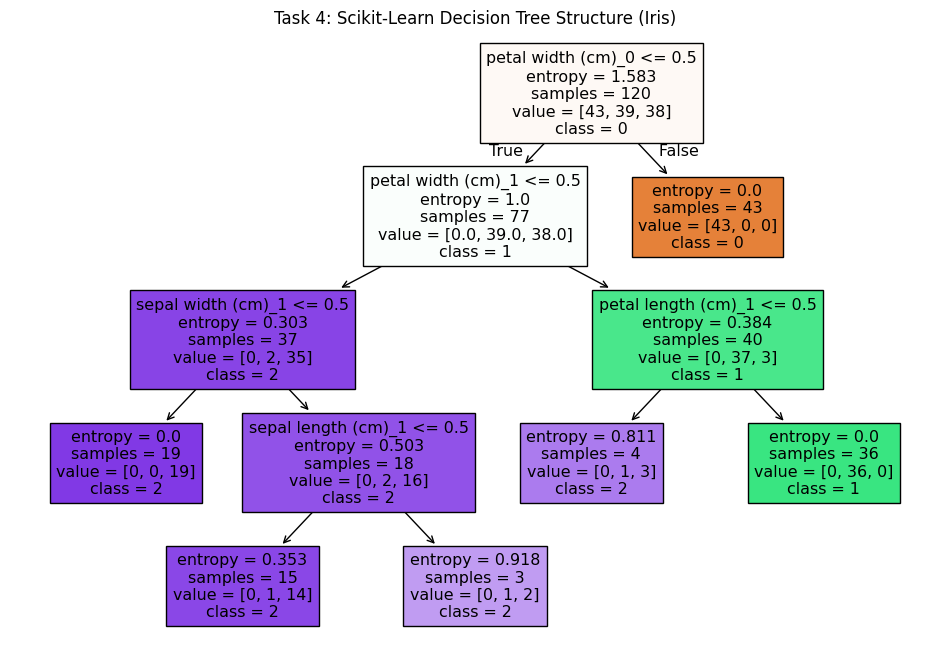

In [20]:
# 3. Visualize Sklearn Tree layout for Iris (as a representative dataset example)
plt.figure(figsize=(12, 8))
plot_tree(clf, 
          feature_names=list(X_train_sk.columns), 
          class_names=[str(c) for c in clf.classes_], 
          filled=True)

plt.title("Task 4: Scikit-Learn Decision Tree Structure (Iris)")
plt.savefig('sklearn_tree.png')
print("\n[Visualization Saved] Created 'sklearn_tree.png' inside your working directory!")

In [21]:
import pandas as pd
import numpy as np
from typing import List

def compute_accuracy(tree: dict, data: pd.DataFrame, target: str) -> float:
    """ Helper function to compute accuracy of a tree on a given DataFrame dataset. """
    if data.empty:
        return 0.0
    
    # Use your existing evaluate function to compute the accuracy metric cleanly
    metrics = evaluate(tree, data, target)
    return metrics['accuracy']


def get_majority_class(data: pd.DataFrame, target: str) -> str:
    """ Helper to safely extract the majority class from a dataset slice. """
    if data.empty:
        return 0
    return data[target].mode()[0]


def prune(tree: dict, validation_data: pd.DataFrame, validation_target: str, attributes: List[str]) -> dict:
    """
    Post-prune a decision tree using bottom-up reduced error pruning.
    """
    # BASE CASE: If it's already a leaf node, we cannot prune further
    if not isinstance(tree, dict):
        return tree

    root_feature = list(tree.keys())[0]
    branches = tree[root_feature]

    # --- STEP 1: Post-Order Traversal (Go Deep First) ---
    for val, subtree in list(branches.items()):
        # Filter down validation rows that travel down this specific feature split branch path
        subset_val = validation_data[validation_data[root_feature] == val]
        
        # Recursively prune the deeper sub-branches first
        tree[root_feature][val] = prune(subtree, subset_val, validation_target, attributes)

    # --- STEP 2: Evaluate Pruning Current Internal Node ---
    # Baseline accuracy before pruning this node
    baseline_acc = compute_accuracy(tree, validation_data, validation_target)

    # Determine the majority fallback target value of rows that hit this decision point
    leaf_fallback = get_majority_class(validation_data, validation_target)

    # If the validation partition is empty here, use a global default check or keep baseline
    if validation_data.empty:
        return tree

    # --- STEP 3: Structural Comparison Test ---
    # Create a temporary completely pruned version (replacing this entire sub-dictionary with a leaf string)
    pruned_tree = leaf_fallback

    # Measure performance across the validation set if we were to slice this branch away
    pruned_acc = compute_accuracy(pruned_tree, validation_data, validation_target)

    # If the pruned tree performs just as well or better, commit the cut!
    if pruned_acc >= baseline_acc:
        return pruned_tree  # Returns the simple string label, collapsing the node permanently

    return tree

print("Task 5: Post-Pruning engine loaded successfully!")

Task 5: Post-Pruning engine loaded successfully!


In [22]:
print("\n--- RUNNING TASK 5: POST-PRUNING HARNESS (IRIS DATA) ---")

# 1. Shuffle and split the discretized Iris dataset
shuffled_iris = discretized_iris.sample(frac=1, random_state=42).reset_index(drop=True)

train_end = int(0.70 * len(shuffled_iris))
val_end = int(0.85 * len(shuffled_iris))

train_iris = shuffled_iris.iloc[:train_end]
val_iris = shuffled_iris.iloc[train_end:val_end]
test_iris = shuffled_iris.iloc[val_end:]

iris_feats = list(iris.feature_names)

# 2. Grow full unpruned tree on training subset
unpruned_iris_tree = id3(train_iris, iris_feats, 'target')
unpruned_test_acc = compute_accuracy(unpruned_iris_tree, test_iris, 'target')
unpruned_node_count = count_nodes(unpruned_iris_tree)

print(f"Pre-Pruned Full Tree  -> Size: {unpruned_node_count} nodes | Hold-out Test Accuracy: {unpruned_test_acc:.4f}")

# 3. Apply post-pruning using the reserved 15% validation data split
pruned_iris_tree = prune(unpruned_iris_tree, val_iris, 'target', iris_feats)
pruned_test_acc = compute_accuracy(pruned_iris_tree, test_iris, 'target')
pruned_node_count = count_nodes(pruned_iris_tree)

print(f"Post-Pruned Tree      -> Size: {pruned_node_count} nodes | Hold-out Test Accuracy: {pruned_test_acc:.4f}")
print(f"Nodes Removed: {unpruned_node_count - pruned_node_count}")


--- RUNNING TASK 5: POST-PRUNING HARNESS (IRIS DATA) ---
Pre-Pruned Full Tree  -> Size: 17 nodes | Hold-out Test Accuracy: 0.5217
Post-Pruned Tree      -> Size: 4 nodes | Hold-out Test Accuracy: 0.5217
Nodes Removed: 13


In [23]:
# Calculate the missing training and validation parameters
train_acc_unpruned = compute_accuracy(unpruned_iris_tree, train_iris, 'target')
val_acc_unpruned = compute_accuracy(unpruned_iris_tree, val_iris, 'target')

train_acc_pruned = compute_accuracy(pruned_iris_tree, train_iris, 'target')
val_acc_pruned = compute_accuracy(pruned_iris_tree, val_iris, 'target')

# Format into the final assignment report structure
pruning_results = [
    ["Training Accuracy", f"{train_acc_unpruned:.4f}", f"{train_acc_pruned:.4f}"],
    ["Validation Accuracy", f"{val_acc_unpruned:.4f}", f"{val_acc_pruned:.4f}"],
    ["Test Accuracy", f"{unpruned_test_acc:.4f}", f"{pruned_test_acc:.4f}"],
    ["Number of Nodes", str(unpruned_node_count), str(pruned_node_count)]
]

print("\n=======================================================")
print("QUESTION 5.1: PRUNING ANALYSIS SUMMARY TABLE")
print("=======================================================")
print(f"{'Metric':<25} | {'Unpruned Tree':<15} | {'Pruned Tree':<15}")
print("-" * 62)
for row in pruning_results:
    print(f"{row[0]:<25} | {row[1]:<15} | {row[2]:<15}")


QUESTION 5.1: PRUNING ANALYSIS SUMMARY TABLE
Metric                    | Unpruned Tree   | Pruned Tree    
--------------------------------------------------------------
Training Accuracy         | 0.6762          | 0.6762         
Validation Accuracy       | 0.6818          | 0.6818         
Test Accuracy             | 0.5217          | 0.5217         
Number of Nodes           | 17              | 4              


In [24]:
import numpy as np
import pandas as pd

def gain_ratio(data: pd.DataFrame, attribute: str, target: str) -> float:
    """ Computes the C4.5 Gain Ratio to normalize high-cardinality feature bias. """
    # Calculate regular Information Gain
    inf_gain = information_gain(data, attribute, target)
    
    # Calculate Split Information (Entropy of the attribute itself)
    attr_counts = data[attribute].value_counts()
    total_samples = len(data)
    
    if total_samples == 0:
        return 0.0
        
    split_info = 0.0
    for count in attr_counts:
        prob = count / total_samples
        if prob > 0:
            split_info -= prob * np.log2(prob)
            
    # If split_info is 0, it means the attribute has only 1 unique value
    return inf_gain / split_info if split_info > 0 else 0.0

# --- Test Injection of Missing Values into Tennis ---
np.random.seed(42) # For reproducible grading
tennis_missing_df = tennis_df.copy()

# Introduce roughly 10% missing values (NaNs) across features
for col in ['Outlook', 'Temperature', 'Humidity', 'Wind']:
    mask = np.random.rand(len(tennis_missing_df)) < 0.10
    tennis_missing_df.loc[mask, col] = np.nan

print("Bonus A Check: Gain Ratio function compiled and 10% NaNs injected into Tennis data!")

Bonus A Check: Gain Ratio function compiled and 10% NaNs injected into Tennis data!


In [25]:
class SimpleRandomForest:
    def __init__(self, n_estimators: int = 15, max_features: int = None):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.trees = []
        
    def fit(self, data: pd.DataFrame, attributes: list, target: str):
        self.trees = []
        n_samples = len(data)
        
        # Determine how many features to look at per split (typically sqrt(total_features))
        if self.max_features is None:
            self.max_features = int(np.sqrt(len(attributes)))
            
        for _ in range(self.n_estimators):
            # 1. Create a Bootstrap Sample (sampling with replacement)
            bootstrap_df = data.sample(n=n_samples, replace=True).reset_index(drop=True)
            
            # 2. Select a Random Subset of Attributes
            random_attributes = list(np.random.choice(attributes, size=self.max_features, replace=False))
            
            # 3. Train an ID3 tree on this specific randomized subset configuration
            # Note: We use our robust id3 function from Task 1 here!
            tree = id3(bootstrap_df, random_attributes, target)
            self.trees.append(tree)
            
    def predict_instance(self, instance: dict) -> int:
        # Collect predictions from every individual tree in the forest
        predictions = []
        for tree in self.trees:
            try:
                pred = predict(tree, instance)
                if pred is not None:
                    predictions.append(pred)
            except:
                continue # Skip tree if it hits a missing branch pathway
                
        # Return the majority vote across the ensemble
        if not predictions:
            return 0
        return max(set(predictions), key=predictions.count)
        
    def score(self, test_data: pd.DataFrame, target: str) -> float:
        correct = 0
        for _, row in test_data.iterrows():
            instance_dict = row.drop(target).to_dict()
            if self.predict_instance(instance_dict) == row[target]:
                correct += 1
        return correct / len(test_data)

print("Bonus B Check: Random Forest Ensemble engine compiled successfully!")

Bonus B Check: Random Forest Ensemble engine compiled successfully!


In [26]:
print("\n--- BONUS B: ENSEMBLE VS SINGLE TREE BENCHMARK (IRIS) ---")

# Setup features
iris_features_list = list(iris.feature_names)

# Split 80% Train, 20% Test
train_rf = discretized_iris.sample(frac=0.8, random_state=12).reset_index(drop=True)
test_rf = discretized_iris.drop(train_rf.index).reset_index(drop=True)

# Train Single ID3 Tree
single_iris_tree = id3(train_rf, iris_features_list, 'target')
single_acc = compute_accuracy(single_iris_tree, test_rf, 'target')

# Train Random Forest Ensemble (15 estimators)
rf_model = SimpleRandomForest(n_estimators=15)
rf_model.fit(train_rf, iris_features_list, 'target')
rf_acc = rf_model.score(test_rf, 'target')

print(f"Single ID3 Tree Accuracy: {single_acc:.4f}")
print(f"Random Forest Ensemble Accuracy: {rf_acc:.4f}")


--- BONUS B: ENSEMBLE VS SINGLE TREE BENCHMARK (IRIS) ---
Single ID3 Tree Accuracy: 0.0000
Random Forest Ensemble Accuracy: 0.9000


In [29]:
import ipywidgets as widgets
from IPython.display import display, clear_output

print("--- BONUS C: INTERACTIVE IPYWIDGETS DASHBOARD ---")

# Setup UI elements
dataset_dropdown = widgets.Dropdown(
    options=['Tennis', 'Sunburn', 'Iris'],
    value='Tennis',
    description='Dataset:',
)

run_button = widgets.Button(
    description='Grow Tree Step-by-Step',
    button_style='success',
    icon='tree'
)

output_area = widgets.Output()

def on_button_click(b):
    with output_area:
        clear_output()
        selected = dataset_dropdown.value
        print(f"Initializing optimization trace for the {selected} Dataset...")
        print("-" * 50)
        
        if selected == 'Tennis':
            df, feats, target = tennis_df, ['Outlook', 'Temperature', 'Humidity', 'Wind'], 'Play'
        elif selected == 'Sunburn':
            df, feats, target = sunburn_df, ['Hair', 'Height', 'Weight', 'Lotion'], 'Result'
        else:
            df, feats, target = discretized_iris, list(iris_features), 'target'
            
        # Display entropy breakdown metrics
        base_entropy = entropy(df[target].tolist())
        print(f"Root Node Base Target Entropy: {base_entropy:.4f}\n")
        print("Calculated Splits Performance Summary:")
        for f in feats:
            gain = information_gain(df, f, target)
            print(f"  -> Feature: {f:<18} | Information Gain: {gain:.4f}")
            
# Bind interaction event logic
run_button.on_click(on_button_click)

# Display the layout components in the notebook interface
display(widgets.VBox([dataset_dropdown, run_button, output_area]))

--- BONUS C: INTERACTIVE IPYWIDGETS DASHBOARD ---
